In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV , train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score ,roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [2]:
df = pd.read_csv("loan_data_new.csv")
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [3]:
df.isnull().sum()

Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [6]:
df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
df[df["Age"]==144]

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
81,144,male,Bachelor,300616,125,RENT,4800,VENTURE,13.57,0.02,3,789,No,0
183,144,male,Associate,241424,121,MORTGAGE,6000,EDUCATION,11.86,0.02,2,807,No,0
32297,144,female,Associate,7200766,124,MORTGAGE,5000,PERSONAL,12.73,0.00,25,850,No,0


In [8]:
df[df["Employee Experience"] >50]

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
81,144,male,Bachelor,300616,125,RENT,4800,VENTURE,13.57,0.02,3,789,No,0
183,144,male,Associate,241424,121,MORTGAGE,6000,EDUCATION,11.86,0.02,2,807,No,0
575,123,female,High School,97140,101,RENT,20400,EDUCATION,10.25,0.21,3,805,Yes,0
747,123,male,Bachelor,94723,100,RENT,20000,VENTURE,11.01,0.21,4,714,Yes,0
32297,144,female,Associate,7200766,124,MORTGAGE,5000,PERSONAL,12.73,0.00,25,850,No,0
32355,78,male,Associate,58463,57,RENT,3000,MEDICAL,7.51,0.05,25,754,No,0
32416,94,male,High School,29738,76,RENT,6500,MEDICAL,11.01,0.22,27,773,No,0
32422,80,male,High School,77894,62,RENT,6800,MEDICAL,11.71,0.09,25,673,No,0
32506,84,male,High School,114705,61,MORTGAGE,10000,PERSONAL,7.51,0.09,24,784,Yes,0
32534,76,female,Bachelor,90934,58,RENT,15000,MEDICAL,8.94,0.16,25,737,No,0


In [9]:
df = df[df["Employee Experience"] <= 80]
df.reset_index(drop=True, inplace=True)


In [10]:
df["Loan Amount"] = df["Loan Amount"]*60
df["Person Income"] = df["Person Income"]*60

In [11]:
df["Loan Amount"].max()

2100000

In [12]:
df["Loan Amount"].min()

30000

In [13]:
df = df[df["Loan Amount"] <1000000]

<Axes: xlabel='Education', ylabel='Loan Amount'>

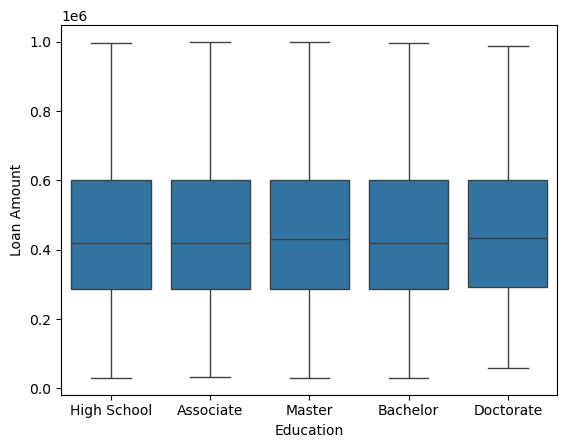

In [14]:
sns.boxplot(x='Education' , y='Loan Amount' , data=df)

<Axes: xlabel='Home Onwership', ylabel='Loan Amount'>

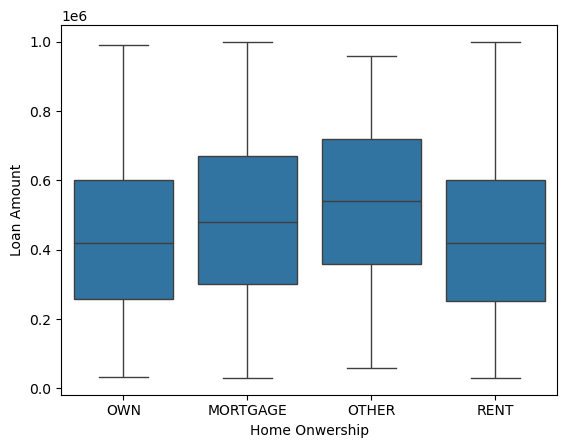

In [15]:
sns.boxplot(x='Home Onwership' , y='Loan Amount' , data=df)

In [16]:
df['Loan Status'].value_counts()

Loan Status
0    31065
1     8036
Name: count, dtype: int64

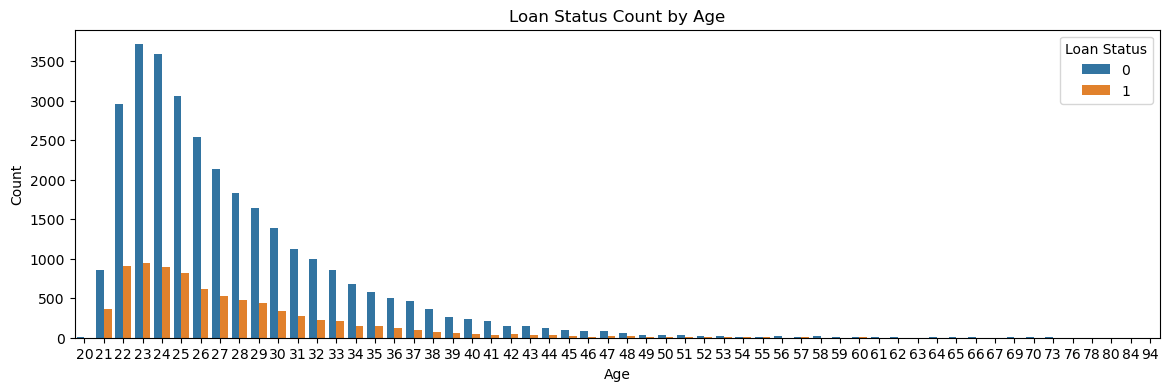

In [17]:
plt.figure(figsize=(14, 4))
sns.countplot(data=df, x="Age", hue="Loan Status")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Loan Status Count by Age")
plt.show()

<Axes: xlabel='Gender', ylabel='count'>

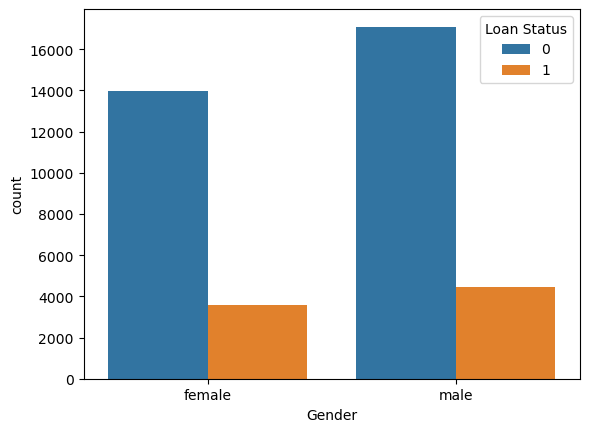

In [18]:
sns.countplot(x='Gender' , hue='Loan Status' , data=df)

<Axes: xlabel='Previous Loan', ylabel='count'>

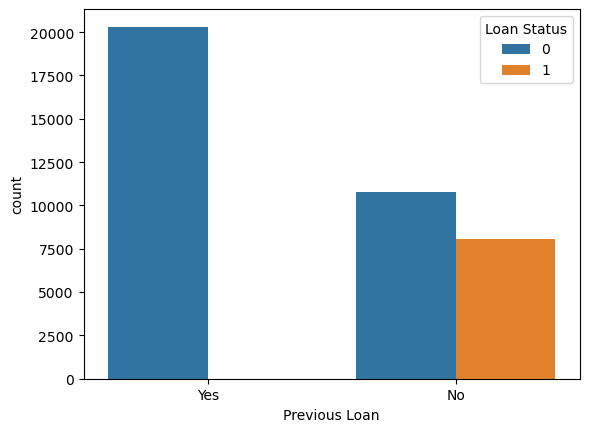

In [19]:
sns.countplot(x='Previous Loan' , hue='Loan Status' , data=df)

<Axes: >

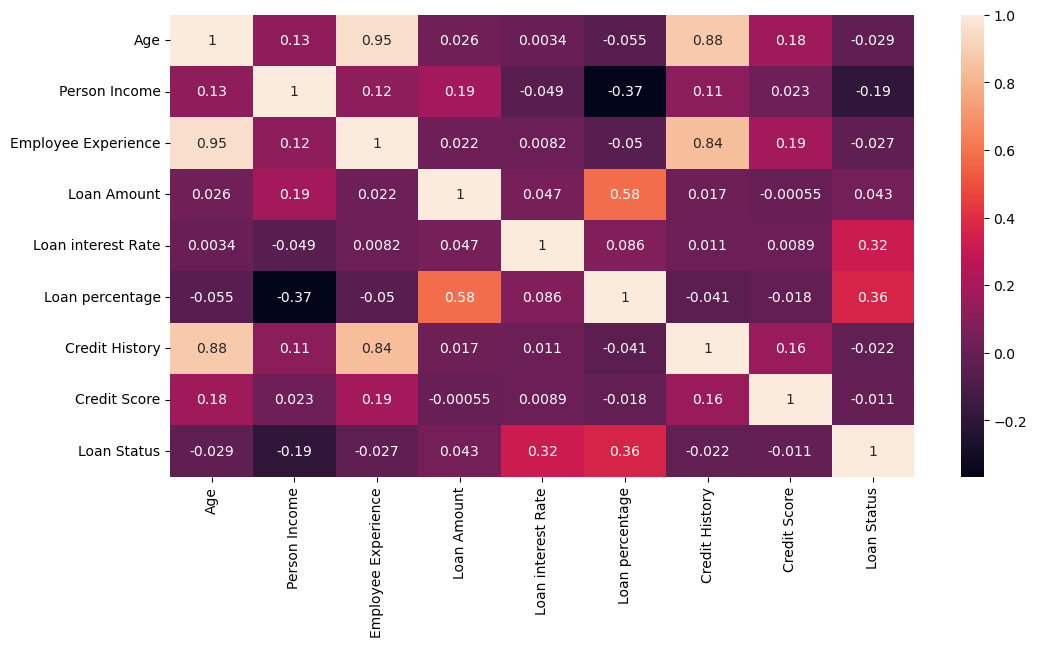

In [20]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)

In [21]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df['Education'] = le.fit_transform(df['Education'])
df['Home Onwership'] = le.fit_transform(df['Home Onwership'])
df['Loan Intent'] = le.fit_transform(df['Loan Intent'])
df['Previous Loan'] = le.fit_transform(df['Previous Loan'])

In [22]:
X = df.drop(columns=['Loan Status', 'Employee Experience', 'Education','Loan Intent' ])
y = df["Loan Status"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
scale = StandardScaler()
X_scaled_train = scale.fit_transform(X_train)
X_scaled_test = scale.transform(X_test)

In [25]:
def evaluate_model(y_test, y_pred, y_prob=None):

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    if y_prob is not None:
        print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

In [26]:
lo = LogisticRegression()
lo.fit(X_scaled_train, y_train)
y_pred = lo.predict(X_scaled_test)
evaluate_model(y_test, y_pred)

Accuracy : 0.8943869070451349
Precision: 0.7545931758530183
Recall   : 0.717852684144819
F1 Score : 0.7357645553422905
Confusion Matrix:
[[5845  374]
 [ 452 1150]]


In [27]:
knc = KNeighborsClassifier()

In [28]:
param = {
    "n_neighbors": [7,9,11,13],
    "weights": ["uniform", "distance"]
}

In [29]:
gridkbc = GridSearchCV(knc, param, cv=5)
gridkbc.fit(X_scaled_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [7, 9, 11, 13],
                         'weights': ['uniform', 'distance']})

In [30]:
gridkbc.best_params_


{'n_neighbors': 13, 'weights': 'distance'}

In [31]:
pred = gridkbc.predict(X_scaled_test)
evaluate_model(y_test, pred)

Accuracy : 0.8996292034266717
Precision: 0.7769491525423728
Recall   : 0.7153558052434457
F1 Score : 0.7448813779655509
Confusion Matrix:
[[5890  329]
 [ 456 1146]]


In [32]:
svm = SVC()

In [33]:
param = {
    "C": [0.01, 0.5,0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"]
}

In [34]:
gridsvc = GridSearchCV(svm, param, cv=5)
gridsvc.fit(X_scaled_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.5, 0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly']})

In [36]:
gridscv.best_params_

NameError: name 'gridscv' is not defined

In [37]:
pred = gridsvc.predict(X_scaled_test)
evaluate_model(y_test, pred)

Accuracy : 0.9110088224012275
Precision: 0.8145833333333333
Recall   : 0.7322097378277154
F1 Score : 0.7712031558185405
Confusion Matrix:
[[5952  267]
 [ 429 1173]]


In [144]:
de = DecisionTreeClassifier()

In [ ]:
param = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15,20,25,30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

In [ ]:
gridde = GridSearchCV(de, param, cv=5)
gridde.fit(X_scaled_train, y_train)

In [ ]:
gridde.best_params_

In [ ]:
pred = gridde.predict(X_scaled_test)
evaluate_model(y_test, pred)

In [39]:
re = RandomForestClassifier()

In [38]:
param = {
    "class_weight": ["balanced"],
    "n_estimators": [60, 80,100],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15,20,25,30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
gridre = GridSearchCV(re, param, cv=5)
gridre.fit(X_scaled_train, y_train)

In [ ]:
gridre.best_params_

In [ ]:
pred = gridre.predict(X_scaled_test)
evaluate_model(y_test, pred)